# Hawaii Fires

### Prepare Workspace

In [1]:
# Load system libraries
import os

# Load progress bar
from tqdm import tqdm

# Load data manipulation libraries
import numpy as np
import pandas as pd
import itertools

# Load data visualisation libraries
import matplotlib.pyplot as plt

# XGBoost related imports
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

from imblearn.over_sampling import SMOTE

### Load the Data

In [2]:
gdf_final = pd.read_csv('../data/gdf_final.csv')

G:\TEMP\ipykernel_14124\4156067892.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  gdf_final = pd.read_csv('../data/gdf_final.csv')


### Perform Analysis

##### *XGBoost of Location on Fire*

Original training set shape: (10585030, 20)
After undersampling + SMOTE: (113260, 20)
Class distribution in the original training set:
fire
0    0.999465
1    0.000535
Name: proportion, dtype: float64

Class distribution after undersampling + SMOTE:
fire
0    0.5
1    0.5
Name: proportion, dtype: float64

Starting hyperparameter tuning on the resampled data...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


h:\Misc Programming\hawaii-wildfire\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:19:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters Found: {'subsample': 0.8, 'n_estimators': 400, 'max_depth': 12, 'learning_rate': 0.15, 'gamma': 0, 'colsample_bytree': 0.9}

Final Classification Report on Test Data:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88   2644842
           1       0.00      0.97      0.00      1416

    accuracy                           0.79   2646258
   macro avg       0.50      0.88      0.44   2646258
weighted avg       1.00      0.79      0.88   2646258

ROC AUC Score: 0.9505


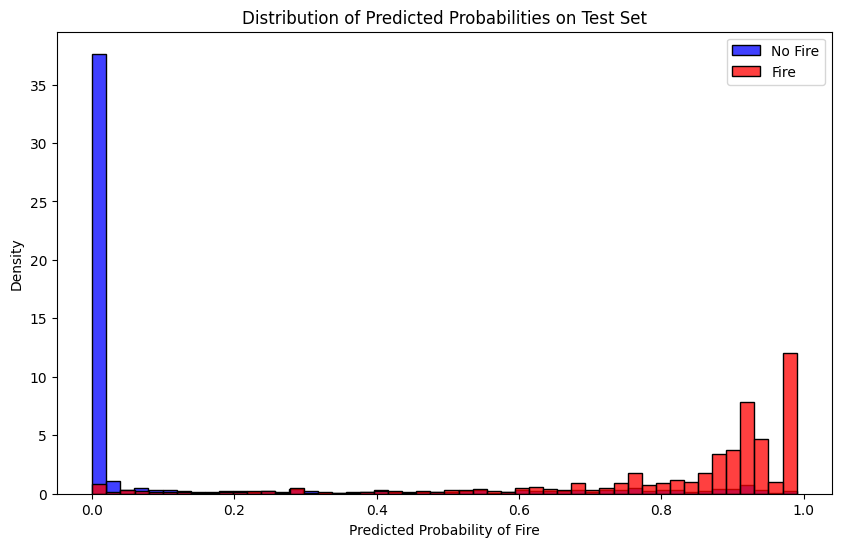

In [ ]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler # Import the undersampler

data = gdf_final.copy()

del gdf_final  # Clean up memory because this is massive

X = data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
          'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
          'barren', 'shrub_grass', 'introduced_dry', 'introduced_wet_mesic',
          'plantation', 'oniTOTAL', 'ninoANOM.1']]
y = data['fire']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



# undersample the majority class
# 1 fire sample for every 10 no-fire samples
under_sampler = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train) # No clue why pylance throws up an error

# oversample the minority class
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_under, y_train_under)

print("Original training set shape:", X_train.shape)
print("After undersampling + SMOTE:", X_train_resampled.shape)

print("Class distribution in the original training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution after undersampling + SMOTE:")
print(y_train_resampled.value_counts(normalize=True))



param_distributions = {
    'n_estimators': [100, 250, 400],
    'max_depth': [5, 8, 10, 12],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9],
    'gamma': [0, 1, 5]
}

xgb_classifier = xgb.XGBClassifier(objective='binary:logistic', random_state=42, use_label_encoder=False, eval_metric='logloss')

random_search = RandomizedSearchCV(
    estimator=xgb_classifier,
    param_distributions=param_distributions,
    n_iter=50,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("\nStarting hyperparameter tuning on the resampled data...")
random_search.fit(X_train_resampled, y_train_resampled)

best_model = random_search.best_estimator_
print(f"\nBest Parameters Found: {random_search.best_params_}")

threshold = 0.1

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_pred_proba >= threshold).astype(int)

print("\nFinal Classification Report on Test Data:")
print(classification_report(y_test, y_pred_final))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


results_df = pd.DataFrame({'true_class': y_test, 'probability': y_pred_proba})
plt.figure(figsize=(10, 6))
sns.histplot(results_df[results_df['true_class'] == 0]['probability'], color="blue", label='No Fire', stat='density', bins=50)
sns.histplot(results_df[results_df['true_class'] == 1]['probability'], color="red", label='Fire', stat='density', bins=50)
plt.title('Distribution of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability of Fire')
plt.legend()
plt.show()


--- DEBUGGING INFO ---
Unique values predicted by the model:
0    2288126
1     358132
Name: count, dtype: int64
--------------------------

Final Classification Report on Test Data:
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   2644842
           1       0.00      0.91      0.01      1416

    accuracy                           0.87   2646258
   macro avg       0.50      0.89      0.47   2646258
weighted avg       1.00      0.87      0.93   2646258


Confusion Matrix:


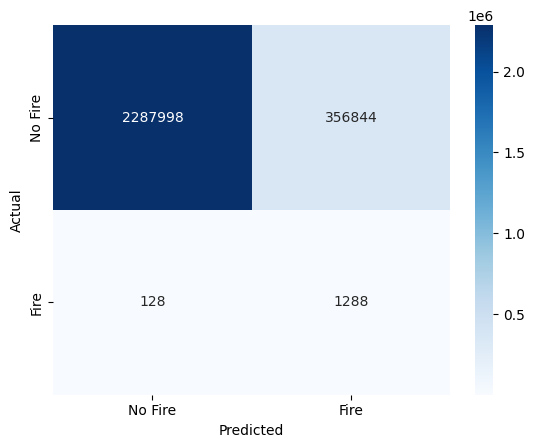

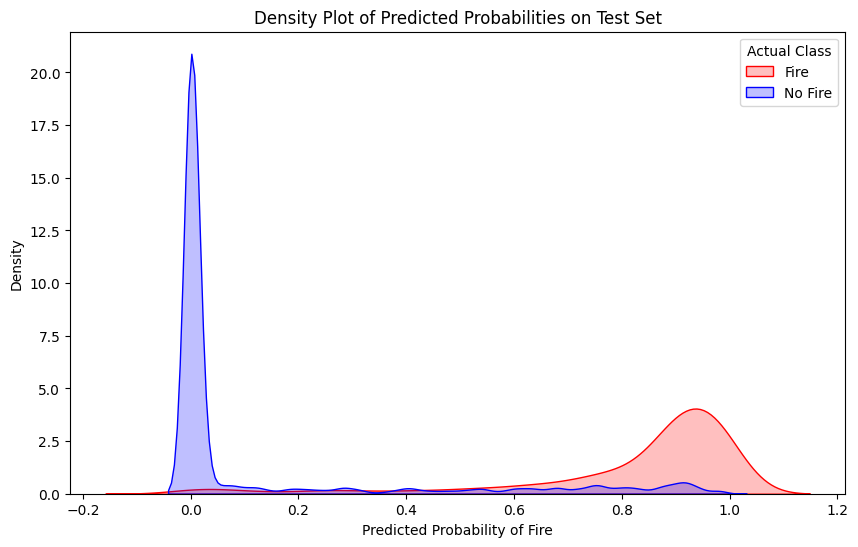

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

best_model = random_search.best_estimator_


y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# default 0.5 threshold
y_pred_final = best_model.predict(X_test)

print("\n--- DEBUGGING INFO ---")
print("Unique values predicted by the model:")
print(pd.Series(y_pred_final).value_counts())
print("--------------------------\n")


print("Final Classification Report on Test Data:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fire', 'Fire'], yticklabels=['No Fire', 'Fire'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()




results_df = pd.DataFrame({'true_class': y_test, 'probability': y_pred_proba})
plt.figure(figsize=(10, 6))
# Plot the KDE for the "No Fire" class
sns.kdeplot(data=results_df, x='probability', hue='true_class', 
            fill=True, common_norm=False, palette=['blue', 'red'])

plt.title('Density Plot of Predicted Probabilities on Test Set')
plt.xlabel('Predicted Probability of Fire')
plt.ylabel('Density')
plt.legend(title='Actual Class', labels=['Fire', 'No Fire'])
plt.show()


##### *Chi-Squared Test of Eucalyptus Grove on Fire*

##### *XGBoost of Fire Location on Fire Area*

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import xgboost as xgb

fire_data = data[data['fire'] == 1]

X_fire = fire_data[['month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8',
                   'month_9', 'month_10', 'month_11', 'month_12', 'urban_dev', 'agriculture',
                    'barren', 'shrub_grass', 'introduced_dry', 'introduced_wet_mesic',
                    'plantation', 'oniTOTAL', 'ninoANOM.1']]
y_fire = fire_data['area_ha']


X_train_fire, X_test_fire, y_train_fire, y_test_fire = train_test_split(
    X_fire, y_fire, test_size=0.2, random_state=42
)


param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 12, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.25],
    'subsample': [0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.85, 0.9, 0.95, 1.0],
    'reg_alpha': [0, 0.1, 0.3, 0.5, 0.7, 1.0],  # L1 regularization
    'reg_lambda': [0.5, 1, 1.2, 1.5, 1.8, 2.0]  # L2 regularization
}

base_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

print("Starting hyperparameter tuning with RandomizedSearchCV...")

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_distributions,
    n_iter=100,  # Number of parameter settings that are sampled
    cv=5,  # 5-fold cross-validation
    # Can also use 'r2' or 'neg_mean_absolute_error'
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available cores
    verbose=1,   # Show progress
    random_state=42  # For reproducible results
)

random_search.fit(X_train_fire, y_train_fire)

print(f"\nBest parameters: {random_search.best_params_}")
print(
    f"Best cross-validation score (neg_MSE): {random_search.best_score_:.4f}")
print(f"Best cross-validation MSE: {-random_search.best_score_:.2f}")

best_model = random_search.best_estimator_
y_pred_fire_tuned = best_model.predict(X_test_fire)

mse_tuned = mean_squared_error(y_test_fire, y_pred_fire_tuned)
r2_tuned = r2_score(y_test_fire, y_pred_fire_tuned)
print(f"\nTuned Model Performance:")
print(f"Mean Squared Error: {mse_tuned:.2f}")
print(f"R² Score: {r2_tuned:.4f}")



Starting hyperparameter tuning with RandomizedSearchCV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters: {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.95}
Best cross-validation score (neg_MSE): -2779038.7875
Best cross-validation MSE: 2779038.79

Tuned Model Performance:
Mean Squared Error: 3625468.72
R² Score: 0.8106

Top 10 parameter combinations:
 1. Score: -2779038.7875 (±392365.1385) - {'subsample': 0.7, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.95}
 2. Score: -2779553.4361 (±393376.7901) - {'subsample': 0.85, 'reg_lambda': 1.2, 'reg_alpha': 0.3, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
 3. Score: -2779627.5050 (±394667.9924) - {'subsample': 0.85, 'reg_lambda': 1.8, 'reg_alpha': 0.1, 'n_estimators': 50, 'max_depth': 15, 'learning_rate': 0

Sources:

https://pacificfireexchange.org/resource/fire-data/

https://www.landfire.gov/data/FullExtentDownloads?field_version_target_id=All&field_theme_target_id=5&field_region_id_target_id=2

https://www.hawaiitourismauthority.org/research/historical-visitor-statistics/